# Georgia Market Risk Analytics

## 1. Setup and imports

In [1]:
import itertools
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.decomposition import PCA
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


## 2. Load cleaned datasets
This notebook starts from the cleaned inputs produced by `data_cleaning.ipynb`.

In [2]:
START = "2018-01-01"
END = "2026-05-08"

DATA_DIR = Path("Data") / "Processed"
OUTPUT_DIR = Path("Output")
OUTPUT_DIR.mkdir(exist_ok=True)

paths = {
    "FX": DATA_DIR / "FX.csv",
    "currencies": DATA_DIR / "currencies.csv",
    "TIBR": DATA_DIR / "TIBR.csv",
    "cryptos": DATA_DIR / "cryptos.csv",
    "commodities": DATA_DIR / "commodities.csv",
    "yields": DATA_DIR / "yields.csv",
    "all_market": DATA_DIR / "all_market.csv",
    "bond_prices_filled": DATA_DIR / "bond_prices_filled.csv",
    "bond_yields_pct": DATA_DIR / "bond_yields_pct.csv",
    "ice_tri_levels": DATA_DIR / "ice_tri_levels.csv",
    "ice_price_levels": DATA_DIR / "ice_price_levels.csv",
    "market_volumes": DATA_DIR / "market_volumes.csv",
}

BOND_META_PATH = Path("Data") / "bond_metadata.csv"


In [3]:
def clean_market_csv(path):

    df = pd.read_csv(path)
    df.columns = df.columns.astype(str).str.strip()

    possible_date_cols = ["Date", "date", "DATE", "Datetime", "datetime"]

    date_col = None
    for col in possible_date_cols:
        if col in df.columns:
            date_col = col
            break

    if date_col is None:
        date_col = df.columns[0]

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.rename(columns={date_col: "Date"})
    df = df.dropna(subset=["Date"])
    df = df.set_index("Date").sort_index()

    df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", case=False, regex=True)]

    df = df[~df.index.duplicated(keep="last")]

    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.replace("%", "", regex=False)
                .str.strip()
                .replace({"": np.nan, "nan": np.nan, "None": np.nan, "-": np.nan})
            )

        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.loc[START:END]

    return df


raw = {name: clean_market_csv(path) for name, path in paths.items()}

raw["ice_tri_levels"] = raw["ice_tri_levels"].drop(columns=["GDGE"], errors="ignore")

raw_summary = pd.DataFrame([
    {
        "dataset": name,
        "start": df.index.min(),
        "end": df.index.max(),
        "rows": df.shape[0],
        "cols": df.shape[1],
        "missing": int(df.isna().sum().sum()),
    }
    for name, df in raw.items()
])
raw_summary


,dataset,start,end,rows,cols,missing
0,FX,2018-01-01,2026-05-08,2174,7,0
1,currencies,2018-01-01,2026-05-08,2174,10,0
2,TIBR,2018-01-03,2026-05-07,2081,4,888
3,cryptos,2018-01-01,2026-05-08,3050,2,0
4,commodities,2018-01-02,2026-05-08,2102,3,3
5,yields,2018-01-02,2026-05-08,2099,3,0
6,all_market,2018-01-01,2026-05-08,2174,12,117
7,bond_prices_filled,2018-01-01,2026-05-08,2186,16,11912
8,bond_yields_pct,2018-01-01,2026-05-08,2186,16,11912
9,ice_tri_levels,2018-01-02,2026-05-08,2185,11,15733


In [4]:
bond_meta = pd.read_csv(BOND_META_PATH)

bond_meta.columns = bond_meta.columns.str.strip().str.lower()

bond_meta["maturity_date"] = pd.to_datetime(
    bond_meta["maturity_date"],
    errors="coerce"
)

bond_meta["issuer"] = bond_meta["issuer"].astype(str).str.strip()

local_bond_issuers = ["Georgia", "TBC_Bank", "Bank_of_Georgia"]
regional_bond_issuers = ["Turkey", "Russia", "Armenia", "Azerbaijan"]

bond_meta["bond_region"] = np.select(
    [
        bond_meta["issuer"].isin(local_bond_issuers),
        bond_meta["issuer"].isin(regional_bond_issuers),
    ],
    [
        "local_georgia",
        "regional",
    ],
    default="other"
)

bond_meta["maturity_year"] = bond_meta["maturity_date"].dt.year

bond_meta[["isin", "issuer", "bond_region", "coupon", "maturity_date", "maturity_year"]].head()
def make_bond_name_map(bond_meta):
    """
    Creates readable names for ISIN columns.
    Example:
    XS2334109423 -> Georgia__XS2334109423__mat2026
    """
    name_map = {}

    for _, row in bond_meta.iterrows():
        isin = row["isin"]
        issuer = row["issuer"]
        mat_year = row["maturity_year"]

        name_map[isin] = f"{issuer}__{isin}__mat{mat_year}"

    return name_map


bond_name_map = make_bond_name_map(bond_meta)
bond_name_map


{'US900123BB58': 'Turkey__US900123BB58__mat2038',
 'US900123AY60': 'Turkey__US900123AY60__mat2036',
 'US900123CB40': 'Turkey__US900123CB40__mat2043',
 'RU000A0JXU14': 'Russia__RU000A0JXU14__mat2047',
 'XS0767473852': 'Russia__XS0767473852__mat2042',
 'XS0088543193': 'Russia__XS0088543193__mat2028',
 'RU000A1006S9': 'Russia__RU000A1006S9__mat2035',
 'XS3020792696': 'Armenia__XS3020792696__mat2035',
 'XS2010028939': 'Armenia__XS2010028939__mat2031',
 'XS2010043904': 'Armenia__XS2010043904__mat2029',
 'XS1678623734': 'Azerbaijan__XS1678623734__mat2032',
 'XS1678623064': 'Azerbaijan__XS1678623064__mat2029',
 'XS2808539410': 'TBC_Bank__XS2808539410__mat2029',
 'XS2334109423': 'Georgia__XS2334109423__mat2026',
 'XS3262542155': 'Georgia__XS3262542155__mat2031',
 'XS2801343414': 'Bank_of_Georgia__XS2801343414__mat2029'}

In [5]:
master_index = raw["FX"].index

ffill_limits = {
    "FX": None,
    "currencies": None,
    "TIBR": 5,
    "cryptos": 3,
    "commodities": 5,
    "yields": 5,
    "all_market": None,
    "bond_prices_filled": None,
    "bond_yields_pct": None,
    "ice_tri_levels": None,
    "ice_price_levels": None,
    "market_volumes": None,
}


def align_to_master(df, master_index, ffill_limit=None):

    out = df.reindex(master_index)

    if ffill_limit is not None:
        out = out.ffill(limit=ffill_limit)

    return out


levels = {
    name: align_to_master(df, master_index, ffill_limits[name])
    for name, df in raw.items()
}
def log_returns(df):

    clean = df.where(df > 0)
    return np.log(clean).diff()


def bps_changes(df):

    return df.diff() * 100


def keep_existing(df, cols):

    return df[[c for c in cols if c in df.columns]].copy()


def prefix(df, prefix_name):

    return df.add_prefix(prefix_name)

aligned_summary = pd.DataFrame([
    {
        "dataset": name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "missing_pct": df.isna().sum().sum() / df.size,
    }
    for name, df in levels.items()
])
aligned_summary


,dataset,rows,cols,missing_pct
0,FX,2174,7,0.000000
1,currencies,2174,10,0.000000
2,TIBR,2174,4,0.107866
3,cryptos,2174,2,0.000000
4,commodities,2174,3,0.000460
5,yields,2174,3,0.000460
6,all_market,2174,12,0.006325
7,bond_prices_filled,2174,16,0.342284
8,bond_yields_pct,2174,16,0.342284
9,ice_tri_levels,2174,11,0.657941


## 3. Build Georgian equity factor
This section builds the common Georgian equity factor from BGEO, TBCG, and CGEO.

In [6]:
# ============================================================
# LOCAL BLOCK
# ============================================================

local_currency_returns = log_returns(levels["FX"])

local_currency_returns = prefix(local_currency_returns, "LOCAL__CURRENCY__")


# TIBR changes
tibr_changes = bps_changes(levels["TIBR"])
tibr_changes = prefix(tibr_changes, "LOCAL__TIBR_BPS_CHG__")


# Georgia ICE government and sovereign TRI indices
ice_geo_gov_cols = ["G0GE", "GJGE", "GAGE", "G1GE", "G2GE", "G3GE", "G4GE"]
ice_geo_usd_cols = ["GDGE"]

ice_geo_cols = ice_geo_gov_cols + ice_geo_usd_cols

ice_geo_returns = log_returns(
    keep_existing(levels["ice_tri_levels"], ice_geo_cols)
)

ice_geo_returns = prefix(ice_geo_returns, "LOCAL__ICE_TRI__")


# Local bond yield changes
local_bond_isins = (
    bond_meta
    .loc[bond_meta["bond_region"] == "local_georgia", "isin"]
    .tolist()
)

local_bond_yields = keep_existing(levels["bond_yields_pct"], local_bond_isins)
local_bond_yield_changes = bps_changes(local_bond_yields)
local_bond_yield_changes = local_bond_yield_changes.rename(columns=bond_name_map)
local_bond_yield_changes = prefix(local_bond_yield_changes, "LOCAL__BOND_YLD_BPS_CHG__")


# Local equity volumes
# market_volumes are already log changes / log returns of volume
market_volume_raw = levels["market_volumes"].copy()

volume_name_map = {
    "BGEO.L": "BGEO",
    "TBCG.L": "TBCG",
    "CGEO.L": "CGEO",
    "AAZ.L": "AAZ",
    "AKBNK.IS": "AKBNK",
    "HSBK.L": "HSBK",
    "^FTMC": "FTMC",
    "BZ=F": "Brent",
    "GC=F": "Gold",
    "HG=F": "Copper",
    "BTC-USD": "BTC",
    "ETH-USD": "ETH"
}

market_volume_returns = market_volume_raw.rename(columns=volume_name_map)

local_volume_cols = ["BGEO", "TBCG", "CGEO"]

local_equity_volume = keep_existing(market_volume_returns, local_volume_cols)
local_equity_volume = prefix(local_equity_volume, "LOCAL__EQUITY_VOLUME__")


X_local = pd.concat(
    [
        local_currency_returns,
        tibr_changes,
        ice_geo_returns,
        local_bond_yield_changes,
        local_equity_volume
    ],
    axis=1
)

X_local = X_local.replace([np.inf, -np.inf], np.nan)



# ============================================================
# REGIONAL BLOCK
# ============================================================

# Regional ICE USD sovereign TRI indices
ice_regional_cols = ["GDAM", "GDAZ", "GDRU", "GDTR"]

ice_regional_returns = log_returns(
    keep_existing(levels["ice_tri_levels"], ice_regional_cols)
)

ice_regional_returns = prefix(ice_regional_returns, "REGIONAL__ICE_TRI__")


# Regional bond yield changes
regional_bond_isins = (
    bond_meta
    .loc[bond_meta["bond_region"] == "regional", "isin"]
    .tolist()
)

regional_bond_yields = keep_existing(levels["bond_yields_pct"], regional_bond_isins)
regional_bond_yield_changes = bps_changes(regional_bond_yields)
regional_bond_yield_changes = regional_bond_yield_changes.rename(columns=bond_name_map)
regional_bond_yield_changes = prefix(regional_bond_yield_changes, "REGIONAL__BOND_YLD_BPS_CHG__")


# Regional market proxies
regional_market_cols = ["AKBNK", "BIST", "MOEX", "AAZ", "HSBK"]

regional_market_returns = log_returns(
    keep_existing(levels["all_market"], regional_market_cols)
)

regional_market_returns = prefix(regional_market_returns, "REGIONAL__MARKET__")


#Regional market volumes
regional_volume_cols = ["AKBNK", "BIST", "MOEX", "AAZ","HSBK"]

regional_market_volume = keep_existing(market_volume_returns, regional_volume_cols)
regional_market_volume = prefix(regional_market_volume, "REGIONAL__MARKET_VOLUME__")



X_regional = pd.concat(
    [
        ice_regional_returns,
        regional_bond_yield_changes,
        regional_market_returns,
        regional_market_volume
    ],
    axis=1
)

X_regional = X_regional.replace([np.inf, -np.inf], np.nan)



# ============================================================
# GLOBAL BLOCK
# ============================================================

# US Treasury yield changes
us_yield_changes = bps_changes(levels["yields"])
us_yield_changes = prefix(us_yield_changes, "GLOBAL__US_YIELD_BPS_CHG__")


# Commodities
commodity_returns = log_returns(levels["commodities"])
commodity_returns = prefix(commodity_returns, "GLOBAL__COMMODITY__")


# Crypto
crypto_returns = log_returns(levels["cryptos"])
crypto_returns = prefix(crypto_returns, "GLOBAL__CRYPTO__")


# Global equity
global_market_cols = ["EUFN", "IXG", "FM", "EEM", "FTMC"]

global_market_returns = log_returns(
    keep_existing(levels["all_market"], global_market_cols)
)

global_market_returns = prefix(global_market_returns, "GLOBAL__MARKET__")


# Global equity volumes
global_equity_volume_cols = ["EUFN", "IXG", "EEM",  "FTMC"]

global_equity_volume = keep_existing(market_volume_returns, global_equity_volume_cols)
global_equity_volume = prefix(global_equity_volume, "GLOBAL__EQUITY_VOLUME__")


#Commodity volumes
commodity_volume_cols = ["Brent", "Gold", "Copper"]

commodity_volume = keep_existing(market_volume_returns, commodity_volume_cols)
commodity_volume = prefix(commodity_volume, "GLOBAL__COMMODITY_VOLUME__")


# Crypto volumes
crypto_volume_cols = ["BTC", "ETH"]

crypto_volume = keep_existing(market_volume_returns, crypto_volume_cols)
crypto_volume = prefix(crypto_volume, "GLOBAL__CRYPTO_VOLUME__")


X_global = pd.concat(
    [
        us_yield_changes,
        commodity_returns,
        crypto_returns,
        global_market_returns,
        global_equity_volume,
        commodity_volume,
        crypto_volume
    ],
    axis=1
)

X_global = X_global.replace([np.inf, -np.inf], np.nan)



# ============================================================
# FULL FEATURE MATRIX
# ============================================================

X_blocks = pd.concat(
    [
        X_local,
        X_regional,
        X_global
    ],
    axis=1
)

X_blocks = X_blocks.replace([np.inf, -np.inf], np.nan)



feature_coverage = pd.DataFrame({
    "non_missing": X_blocks.notna().sum(),
    "missing": X_blocks.isna().sum(),
    "coverage": X_blocks.notna().mean()
}).sort_values("coverage")


feature_coverage.head(10)

coverage_threshold = .80


coverage = X_blocks.notna().mean()


last_dates = X_blocks.apply(lambda col: col.last_valid_index())


cols_to_drop = [
    col for col in X_blocks.columns 
    if (coverage[col] < coverage_threshold)
]


X_blocks = X_blocks.drop(columns=cols_to_drop)
X_blocks.shape

block_shapes = pd.Series({
    "local_features": X_local.shape[1],
    "regional_features": X_regional.shape[1],
    "global_features": X_global.shape[1],
    "covered_features": X_blocks.shape[1],
})
block_shapes


local_features       25
regional_features    26
global_features      21
covered_features     54
dtype: int64

In [7]:
target_stocks = ["BGEO", "TBCG", "CGEO"]

target_prices = keep_existing(levels["all_market"], target_stocks)
target_log_prices = np.log(target_prices.where(target_prices > 0))

target_returns_1d = target_log_prices.diff()

indiv_1d = target_returns_1d.add_suffix('_1D')

pca_data = target_returns_1d.dropna()
scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_data)

pca = PCA(n_components=1)
pca_scores = pca.fit_transform(pca_scaled).flatten()

avg_stock_vol = target_returns_1d.std().mean()

georgia_factor_return_scale = (pca_scores / np.std(pca_scores)) * avg_stock_vol

georgia_factor = pd.Series(
    georgia_factor_return_scale, 
    index=pca_data.index, 
    name="FACTOR_GEORGIA_PC1"
)

cgeo_clean_1d = (target_returns_1d['CGEO'] - (0.472 * target_returns_1d['BGEO'])).rename("CGEO_RESIDUAL_1D")

targets_final = pd.concat([
    indiv_1d, 
    georgia_factor, 
    cgeo_clean_1d
], axis=1)

georgia_factor_summary = pd.DataFrame({
    "metric": ["PC1 explained variance", "start", "end", "observations"],
    "value": [
        f"{pca.explained_variance_ratio_[0]:.2%}",
        georgia_factor.index.min().date(),
        georgia_factor.index.max().date(),
        georgia_factor.shape[0],
    ],
})
georgia_factor_summary


,metric,value
0,PC1 explained variance,64.56%
1,start,2018-05-30
2,end,2026-05-08
3,observations,2059


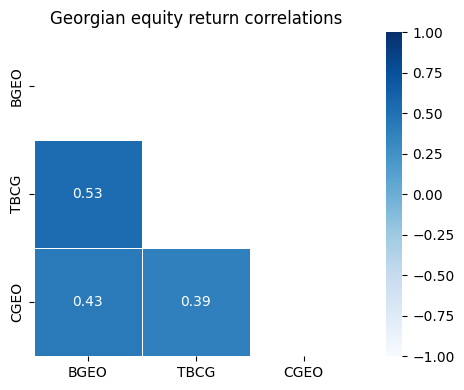

In [8]:
corr = target_returns_1d[target_stocks].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="Blues",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
)
plt.title("Georgian equity return correlations")
plt.tight_layout()
plt.show()


## 4. Build economic blocks
The blocks below use the final naming convention used by the dashboard exports.

In [9]:
regional_ice_indices = X_regional[
    [c for c in X_regional.columns if "REGIONAL__ICE_TRI__" in c]
].copy()

russia_credit = X_regional[
    [
        c for c in X_regional.columns
        if (
            "Russia" in c
            or "REGIONAL__ICE_TRI__GDRU" in c
        )
    ]
].copy()

regional_bond_yields_ex_russia = X_regional[
    [
        c for c in X_regional.columns
        if (
            "REGIONAL__BOND_YLD_BPS_CHG__" in c
            and "Russia" not in c
        )
    ]
].copy()

# Optional: drop very sparse / short-history bond if needed
regional_bond_yields_ex_russia = regional_bond_yields_ex_russia.drop(
    columns=[
        c for c in [
            "REGIONAL__BOND_YLD_BPS_CHG__Armenia__XS3020792696__mat2035"
        ]
        if c in regional_bond_yields_ex_russia.columns
    ],
    errors="ignore"
)


economic_blocks = {}

# 1. Local currency
economic_blocks["LOCAL_CURRENCY"] = X_local[
    [c for c in X_local.columns if "LOCAL__CURRENCY__" in c]
]

# 2. Local interest rates
economic_blocks["LOCAL_RATES"] = X_local[
    [c for c in X_local.columns if "TIBR" in c]
]

# 3. Local credit
economic_blocks["LOCAL_CREDIT"] = X_local[
    [c for c in X_local.columns if "BOND_YLD" in c or "ICE_TRI" in c]
]

# 4. Local equity trading activity
economic_blocks["LOCAL_EQUITY_VOLUME"] = X_local[
    [c for c in X_local.columns if "EQUITY_VOLUME" in c]
]

# 5. Regional ICE bond indices
economic_blocks["REGIONAL_ICE_INDICES"] = regional_ice_indices.drop(columns=["REGIONAL__ICE_TRI__GDRU"])

# 6. Regional bond yields excluding Russia
economic_blocks["REGIONAL_BOND_YIELDS_EX_RUSSIA"] = regional_bond_yields_ex_russia

# 7. Russia credit
economic_blocks["RUSSIA_CREDIT"] = russia_credit.drop(columns=["REGIONAL__ICE_TRI__GDRU"])

# 8. Regional equities / market proxies
economic_blocks["REGIONAL_EQUITY"] = X_regional[
    [c for c in X_regional.columns if "REGIONAL__MARKET__" in c]
]

# 9. Regional market trading activity
economic_blocks["REGIONAL_MARKET_VOLUME"] = X_regional[
    [c for c in X_regional.columns if "MARKET_VOLUME" in c]
]

# 10. Global equities / risk appetite
economic_blocks["GLOBAL_EQUITY_RISK"] = X_global[
    [c for c in X_global.columns if "GLOBAL__MARKET__" in c]
]

# 11. Global equity trading activity
economic_blocks["GLOBAL_EQUITY_VOLUME"] = X_global[
    [c for c in X_global.columns if "GLOBAL__EQUITY_VOLUME__" in c]
]

# 12. US Treasury rates
economic_blocks["GLOBAL_RATES"] = X_global[
    [c for c in X_global.columns if "US_YIELD" in c]
]

# 13. Commodities
economic_blocks["COMMODITIES"] = X_global[
    [c for c in X_global.columns if "GLOBAL__COMMODITY__" in c]
]

# 14. Commodity trading activity
economic_blocks["COMMODITY_VOLUME"] = X_global[
    [c for c in X_global.columns if "COMMODITY_VOLUME" in c]
]

# 15. Crypto
economic_blocks["CRYPTO"] = X_global[
    [c for c in X_global.columns if "GLOBAL__CRYPTO__" in c]
]

# 16. Crypto trading activity
economic_blocks["CRYPTO_VOLUME"] = X_global[
    [c for c in X_global.columns if "CRYPTO_VOLUME" in c]
]


economic_block_shapes = pd.Series({name: block.shape[1] for name, block in economic_blocks.items()}, name="features")
economic_block_shapes

bond_yields = economic_blocks['REGIONAL_BOND_YIELDS_EX_RUSSIA'].copy()

imputer = IterativeImputer(max_iter=10, random_state=42)
economic_blocks['REGIONAL_BOND_YIELDS_EX_RUSSIA'] = pd.DataFrame(
    imputer.fit_transform(bond_yields), 
    index=bond_yields.index, 
    columns=bond_yields.columns
)


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


## 5. PCA factor construction
PCA compresses each economic block into a small set of standardized factors.

In [10]:
def feature_diagnostics(X):

    rows = []

    for col in X.columns:
        s = X[col]

        rows.append({
            "feature": col,
            "first_valid": s.first_valid_index(),
            "last_valid": s.last_valid_index(),
            "non_missing": s.notna().sum(),
            "missing": s.isna().sum(),
            "coverage": s.notna().mean()
        })

    return (
        pd.DataFrame(rows)
        .set_index("feature")
        .sort_values("coverage")
    )


def run_block_pca_safe(
    X_block,
    block_name,
    n_components=5,
    min_coverage=0.70,
    start=None,
    end=None,
    min_obs_warning=252
):


    Xw = X_block.copy()
    Xw = Xw.replace([np.inf, -np.inf], np.nan)

    if start is not None:
        Xw = Xw.loc[start:]

    if end is not None:
        Xw = Xw.loc[:end]

    diag = feature_diagnostics(Xw)

    kept_cols = diag.loc[diag["coverage"] >= min_coverage].index.tolist()
    dropped_cols = diag.loc[diag["coverage"] < min_coverage].index.tolist()

    if len(kept_cols) == 0:
        raise ValueError(f"No columns kept for {block_name}. Lower min_coverage or change sample window.")

    kept_first_valid = diag.loc[kept_cols, "first_valid"].dropna()

    pca_start = kept_first_valid.max()

    Xp = Xw.loc[pca_start:, kept_cols].copy()
    Xp = Xp.dropna(how="all")

    if Xp.shape[0] < min_obs_warning:
        print(
            f"Warning: {block_name} has only {Xp.shape[0]} observations. "
            f"This is okay for descriptive PCA, but weak for ML/backtesting."
        )

    n_components_actual = min(n_components, Xp.shape[0], Xp.shape[1])

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    pca = PCA(n_components=n_components_actual)

    X_imputed = imputer.fit_transform(Xp)
    X_scaled = scaler.fit_transform(X_imputed)

    scores_array = pca.fit_transform(X_scaled)

    pc_cols = [f"{block_name}_PC{i+1}" for i in range(n_components_actual)]

    scores = pd.DataFrame(
        scores_array,
        index=Xp.index,
        columns=pc_cols
    )

    loadings = pd.DataFrame(
        pca.components_.T,
        index=kept_cols,
        columns=pc_cols
    )

    explained_variance = pd.DataFrame({
        "PC": pc_cols,
        "explained_variance": pca.explained_variance_,
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_variance_ratio": np.cumsum(pca.explained_variance_ratio_)
    })

    report = {
        "block": block_name,
        "scores": scores,
        "loadings": loadings,
        "explained_variance": explained_variance,
        "diagnostics": diag,
        "kept_cols": kept_cols,
        "dropped_cols": dropped_cols,
        "pca_start": pca_start,
        "pca_end": Xp.index.max(),
        "imputer": imputer,
        "scaler": scaler,
        "pca": pca
    }

    return report


In [11]:
def pca_block_summary(X_block, block_name, min_coverage=0.70, n_components=5):
    report = run_block_pca_safe(
        X_block,
        block_name=block_name,
        n_components=n_components,
        min_coverage=min_coverage
    )

    ev = report["explained_variance"].copy()
    ev["block"] = block_name
    ev["n_features"] = len(report["kept_cols"])
    ev["pca_start"] = report["pca_start"]
    ev["pca_end"] = report["pca_end"]

    return report, ev


pca_reports = {}
pca_summaries = []
skipped_pca_blocks = {}

for name, block in economic_blocks.items():
    if block.shape[1] < 2:
        continue

    try:
        report, summary = pca_block_summary(
            block,
            block_name=name,
            min_coverage=0.80,
            n_components=5
        )

        pca_reports[name] = report
        pca_summaries.append(summary)

    except Exception as e:
        skipped_pca_blocks[name] = str(e)

pca_summary_table = pd.concat(pca_summaries, ignore_index=True)
pca_summary_table.head(10)

X_economic_pca_factors = pd.concat(
    [report["scores"] for report in pca_reports.values()],
    axis=1
).sort_index()
X_economic_pca_factors = X_economic_pca_factors.ffill(limit=5).dropna()
X_economic_pca_factors.head()

selected_pcs_parsimonious = [
    # PC1-PC3 captures 84% of variance. 
    "LOCAL_CURRENCY_PC1", 
    "LOCAL_CURRENCY_PC2",
    "LOCAL_CURRENCY_PC3",

    # LOCAL RATES (Georgia Refinancing/TIBR)
    # PC1-PC2 captures 82%. 
    # Direct impact on Net Interest Margins (NIM) for TBCG/BGEO.
    #"LOCAL_RATES_PC1",
    "LOCAL_RATES_PC2",

    # LOCAL EQUITY VOLUME
    # PC1-PC2 captures 75%. 
    # Vital for validating CUSUM triggers in Georgian stocks.
    #"LOCAL_EQUITY_VOLUME_PC1",
    #"LOCAL_EQUITY_VOLUME_PC2",

    # REGIONAL CREDIT & INDICES (The "Caucasus/Turkey/Russia" Risk)
    # RUSSIA_CREDIT PC1 is a powerhouse (85% variance).
    # Bond Yields (Ex-Russia) PC1-PC3 captures 80%.
    #"RUSSIA_CREDIT_PC1",
    #"REGIONAL_BOND_YIELDS_EX_RUSSIA_PC1",
    #"REGIONAL_BOND_YIELDS_EX_RUSSIA_PC2",
    #"REGIONAL_BOND_YIELDS_EX_RUSSIA_PC3",
    "REGIONAL_ICE_INDICES_PC1",

    # REGIONAL EQUITY & VOLUME
    # PC1-PC3 captures 77% of price moves and 72% of volume moves.
    "REGIONAL_EQUITY_PC1",
    "REGIONAL_EQUITY_PC2",
    "REGIONAL_EQUITY_PC3",
    "REGIONAL_MARKET_VOLUME_PC1",
    #"REGIONAL_MARKET_VOLUME_PC2",
    #"REGIONAL_MARKET_VOLUME_PC3",

    # GLOBAL EQUITY RISK (S&P 500 / MSCI EM)
    # PC1-PC2 captures 90% of the global "Risk-On" sentiment.
    "GLOBAL_EQUITY_RISK_PC1",
    "GLOBAL_EQUITY_RISK_PC2",
    
    # GLOBAL EQUITY VOLUME
    # PC1-PC3 captures 80% of global turnover shocks.
    #"GLOBAL_EQUITY_VOLUME_PC1",
    #"GLOBAL_EQUITY_VOLUME_PC2",
    #"GLOBAL_EQUITY_VOLUME_PC3",

    # GLOBAL RATES (US 10Y / G7 Yields)
    # PC1-PC2 captures a massive 98% of variance.
    "GLOBAL_RATES_PC1",
    "GLOBAL_RATES_PC2",

    # COMMODITIES (Gold, Oil, Copper)
    # PC1-PC2 captures 78% of price and 76% of volume.
    "COMMODITIES_PC1",
    "COMMODITIES_PC2",
    "COMMODITY_VOLUME_PC1",
    "COMMODITY_VOLUME_PC2",

    # CRYPTO
    # 90%+ variance captured in the first component of both price and volume.
    "CRYPTO_PC1",
    "CRYPTO_VOLUME_PC1"
]

X_selected_parsimonious = X_economic_pca_factors[selected_pcs_parsimonious].copy()

selected_pca_summary = pd.DataFrame({
    "selected_factors": [X_selected_parsimonious.shape[1]],
    "start": [X_selected_parsimonious.index.min()],
    "end": [X_selected_parsimonious.index.max()],
    "skipped_blocks": [", ".join(skipped_pca_blocks) if skipped_pca_blocks else "None"],
})
selected_pca_summary


/tmp/ipykernel_25755/1152865511.py:43: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  X_economic_pca_factors = pd.concat(


,selected_factors,start,end,skipped_blocks
0,19,2019-03-14,2026-05-08,LOCAL_CREDIT


In [12]:
X_core_pca = X_selected_parsimonious.shift(0)
model_data_core_pca = pd.concat(
    [
        targets_final,
        X_core_pca
    ],
    axis=1
).dropna()

y = model_data_core_pca["FACTOR_GEORGIA_PC1"]
X = model_data_core_pca.drop(columns=["FACTOR_GEORGIA_PC1","BGEO_1D","TBCG_1D","CGEO_1D","CGEO_RESIDUAL_1D",
                                     ])

model_data_summary = pd.Series({
    "rows": model_data_core_pca.shape[0],
    "columns": model_data_core_pca.shape[1],
    "start": model_data_core_pca.index.min(),
    "end": model_data_core_pca.index.max(),
})
model_data_summary


rows                      1840
columns                     24
start      2019-03-14 00:00:00
end        2026-05-08 00:00:00
dtype: object

## 6. Same-day diagnostic model
Lasso is used here for same-day attribution, not prediction.

In [13]:
def evaluate_predictions(y_true, y_pred, model_name):
    y_true = pd.Series(y_true).copy()
    y_pred = pd.Series(y_pred, index=y_true.index).copy()

    return {
        "model": model_name,
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
        "corr": y_true.corr(y_pred),
        "direction_accuracy": (np.sign(y_true) == np.sign(y_pred)).mean()
    }


In [14]:
block_prefixes = {
    "LOCAL_CURRENCY": ["LOCAL_CURRENCY_"],
    "LOCAL_RATES": ["LOCAL_RATES_"],
    
    "REGIONAL_ICE_INDICES": ["REGIONAL_ICE_INDICES_"],
    "REGIONAL_EQUITY": ["REGIONAL_EQUITY_"],
    "REGIONAL_MARKET_VOLUME": ["REGIONAL_MARKET_VOLUME_"],

    "GLOBAL_EQUITY_RISK": ["GLOBAL_EQUITY_RISK_"],
    "GLOBAL_RATES": ["GLOBAL_RATES_"],

    "COMMODITIES": ["COMMODITIES_"],
    "COMMODITY_VOLUME": ["COMMODITY_VOLUME_"],

    "CRYPTO": ["CRYPTO_PC"],        # FIX: Changed from "CRYPTO" to "CRYPTO_PC"
    "CRYPTO_VOLUME": ["CRYPTO_VOLUME_"],

    "VOLUME_ALL": [
        "REGIONAL_MARKET_VOLUME_",
        "COMMODITY_VOLUME_",
        "CRYPTO_VOLUME_"
    ],

    "PRICE_MACRO_ALL": [
        "LOCAL_CURRENCY_",
        "LOCAL_RATES_",
        "REGIONAL_ICE_INDICES_",
        "REGIONAL_EQUITY_",
        "GLOBAL_EQUITY_RISK_",
        "GLOBAL_RATES_",
        "COMMODITIES_",
        "CRYPTO_PC"
    ],

    "OPTIMIZED_MODEL": [
        "GLOBAL_EQUITY_RISK_",
        "REGIONAL_ICE_INDICES_",
        "REGIONAL_EQUITY_"
    ],

    "ALL_SELECTED": [
        "LOCAL_CURRENCY_",
        "LOCAL_RATES_",
        "REGIONAL_ICE_INDICES_",
        "REGIONAL_EQUITY_",
        "REGIONAL_MARKET_VOLUME_",
        "GLOBAL_EQUITY_RISK_",
        "GLOBAL_RATES_",
        "COMMODITIES_",
        "COMMODITY_VOLUME_",
        "CRYPTO_PC",
        "CRYPTO_VOLUME_"
    ]
}


In [15]:
factor_name_map = {
    # Macro / Price Factors
    "GLOBAL_EQUITY_RISK": "Global equities",
    "GLOBAL_RATES": "US Treasury rates",
    "REGIONAL_EQUITY": "Regional equities",
    "REGIONAL_ICE_INDICES": "Regional ICE bond indices",
    "LOCAL_CURRENCY": "Local currency",
    "LOCAL_RATES": "Local interest rates",
    "COMMODITIES": "Commodities",
    "CRYPTO": "Crypto",

    # Volume Factors
    "REGIONAL_MARKET_VOLUME": "Regional market volumes",
    "COMMODITY_VOLUME": "Commodity volumes",
    "CRYPTO_VOLUME": "Crypto volumes",
    
    # Composite Blocks (for the Ablation Results)
    "PRICE_MACRO_ALL": "All Price Factors",
    "VOLUME_ALL": "All Volume Factors",
    "REGIONAL_ALL": "All Regional Factors",
    "ALL_SELECTED": "Full Parsimonious Model"
}

# Ordered from most global/macro to specific/volume shocks
factor_order = [
    "Full Parsimonious Model",
    "All Price Factors",
    "All Regional Factors",
    "Global equities",
    "US Treasury rates",
    "Regional equities",
    "Regional ICE bond indices",
    "Local currency",
    "Local interest rates",
    "Commodities",
    "Crypto",
    "All Volume Factors",
    "Regional market volumes",
    "Commodity volumes",
    "Crypto volumes"
]


In [16]:
def lasso_factor_attribution(
    X,
    y,
    factor_name_map,
    factor_order,
    split_date="2025-01-01",
    alphas=np.logspace(-5, 1, 100)
):
    split_date = pd.Timestamp(split_date)

    X_train = X.loc[X.index < split_date].copy()
    y_train = y.loc[y.index < split_date].copy()
    X_test = X.loc[X.index >= split_date].copy()
    y_test = y.loc[y.index >= split_date].copy()

    common_train = X_train.index.intersection(y_train.index)
    common_test = X_test.index.intersection(y_test.index)

    X_train, y_train = X_train.loc[common_train], y_train.loc[common_train]
    X_test, y_test = X_test.loc[common_test], y_test.loc[common_test]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LassoCV(
            alphas=alphas,
            cv=TimeSeriesSplit(n_splits=5),
            max_iter=10000,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    scaler = model.named_steps["scaler"]
    lasso = model.named_steps["model"]

    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        index=X_test.index,
        columns=X_test.columns
    )

    feature_contrib = X_test_scaled.mul(lasso.coef_, axis=1)

    block_contrib = pd.DataFrame(index=X_test.index)

    for prefix, clean_name in factor_name_map.items():
        cols = [c for c in feature_contrib.columns if c.startswith(prefix)]
        
        if len(cols) > 0:
            block_contrib[clean_name] = feature_contrib[cols].sum(axis=1)

    existing_order = [c for c in factor_order if c in block_contrib.columns]
    block_contrib = block_contrib[existing_order]

    intercept = lasso.intercept_
    y_pred = block_contrib.sum(axis=1) + intercept
    y_pred.name = "Predicted"

    n_active = np.sum(lasso.coef_ != 0)

    metrics = {
        "r2": r2_score(y_test, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
        "mae": mean_absolute_error(y_test, y_pred),
        "corr": y_test.corr(y_pred),
        "direction_accuracy": (np.sign(y_test) == np.sign(y_pred)).mean(),
        "selected_alpha": lasso.alpha_,
        "intercept": intercept,
        "n_features_active": n_active,
        "n_features_total": len(lasso.coef_)
    }

    return {
        "model": model,
        "y_test": y_test,
        "y_pred": y_pred,
        "feature_contrib": feature_contrib,
        "block_contrib": block_contrib,
        "metrics": metrics
    }


In [17]:
lasso_attribution = {
    "2025-01-01": lasso_factor_attribution(
        X=X,
        y=y,
        factor_name_map=factor_name_map,
        factor_order=factor_order,
        split_date="2025-01-01",
    ),
    "2026-01-01": lasso_factor_attribution(
        X=X,
        y=y,
        factor_name_map=factor_name_map,
        factor_order=factor_order,
        split_date="2026-01-01",
    ),
}

same_day_diagnostics = pd.DataFrame([
    {
        "split_date": split,
        **out["metrics"],
    }
    for split, out in lasso_attribution.items()
])

attrib = lasso_attribution["2025-01-01"]
same_day_diagnostics[["split_date", "r2", "corr", "rmse", "mae", "n_features_active", "n_features_total"]]


,split_date,r2,corr,rmse,mae,n_features_active,n_features_total
0,2025-01-01,0.367077,0.649992,0.018324,0.013700,15,19
1,2026-01-01,0.450440,0.734420,0.017617,0.013422,9,19


### Dashboard attribution exports

In [18]:
# 1. Chart: Market Performance (Actual vs Model)
perf_df = pd.DataFrame({
    "Georgian Market": attrib["y_test"].cumsum(),
    "Model Explanation": (attrib["y_pred"] - attrib["metrics"]["intercept"]).cumsum()
})
perf_df.index.name = "Date"
perf_df.to_csv(OUTPUT_DIR / "market_performance.csv")

# 2. Chart: Key Drivers (Top 10 Individual Factors)
block_contrib = attrib["block_contrib"].copy()
top_factors = block_contrib.abs().mean().sort_values(ascending=False).head(10).index.tolist()
drivers_df = block_contrib[top_factors].cumsum()
# Use readable names for columns
drivers_df.columns = [factor_name_map.get(col, col) for col in drivers_df.columns]
drivers_df.index.name = "Date"
drivers_df.to_csv(OUTPUT_DIR / "factor_drivers.csv")

# 3. Chart: Rolling Correlation (20, 30, 60 Days)
y_test = attrib["y_test"]
y_pred = attrib["y_pred"]
corr_df = pd.DataFrame({
    "Correlation_20D": y_test.rolling(20).corr(y_pred),
    "Correlation_30D": y_test.rolling(30).corr(y_pred),
    "Correlation_60D": y_test.rolling(60).corr(y_pred)
}, index=y_test.index)
corr_df.index.name = "Date"
corr_df.to_csv(OUTPUT_DIR / "rolling_correlation.csv")

# 4. Chart: Impact Shares (Bar Chart)
impact = block_contrib.abs().mean()
shares = (impact / impact.sum()).sort_values(ascending=False)
shares_df = pd.DataFrame({
    "Factor": [factor_name_map.get(idx, idx) for idx in shares.index],
    "Share": shares.values
})
shares_df.to_csv(OUTPUT_DIR / "impact_shares.csv", index=False)

print("Exported attribution CSVs to", OUTPUT_DIR)


Exported attribution CSVs to Output


In [19]:
feature_label_map = {
    # --- GLOBAL EQUITIES ---
    "GLOBAL__MARKET__IXG": "IXG: iShares Global Financials ETF",
    "GLOBAL__MARKET__EUFN": "EUFN: iShares Europe Financials ETF",
    "GLOBAL__MARKET__EEM": "EEM: iShares Emerging Markets ETF",
    "GLOBAL__MARKET__FM": "FM: iShares Frontier Markets ETF",
    "GLOBAL__MARKET__FTMC": "FTSE 250: UK Mid-Cap Index",
    "GLOBAL__MARKET__HSBK": "HSBK: Halyk Bank (Kazakhstan)",

    # Keep old aliases too, in case older PCA objects still use them
    "GLOBAL__MARKET_USD__IXG": "IXG: iShares Global Financials ETF",
    "GLOBAL__MARKET_USD__EUFN": "EUFN: iShares Europe Financials ETF",
    "GLOBAL__MARKET_USD__EEM": "EEM: iShares Emerging Markets ETF",
    "GLOBAL__MARKET_USD__FM": "FM: iShares Frontier Markets ETF",
    "GLOBAL__MARKET_USD__FTMC": "FTSE 250: UK Mid-Cap Index",
    "GLOBAL__MARKET_USD__HSBK": "HSBK: Halyk Bank (Kazakhstan)",

    # --- US RATES ---
    "GLOBAL__US_YIELD_BPS_CHG__US2Y": "US 2Y Treasury Yield",
    "GLOBAL__US_YIELD_BPS_CHG__US5Y": "US 5Y Treasury Yield",
    "GLOBAL__US_YIELD_BPS_CHG__US10Y": "US 10Y Treasury Yield",

    # --- COMMODITIES ---
    "GLOBAL__COMMODITY__Brent": "Brent Crude Oil",
    "GLOBAL__COMMODITY__Gold": "Gold Spot Price",
    "GLOBAL__COMMODITY__Copper": "Copper Spot Price",

    # --- CRYPTO ---
    "GLOBAL__CRYPTO__BTC": "Bitcoin (BTC)",
    "GLOBAL__CRYPTO__ETH": "Ethereum (ETH)",

    # Keep old aliases too
    "LOCAL__FX_GEL__USDGEL": "USD/GEL",
    "LOCAL__FX_GEL__EURGEL": "EUR/GEL",
    "LOCAL__FX_GEL__GBPGEL": "GBP/GEL",
    "LOCAL__FX_GEL__RUBGEL": "RUB/GEL",
    "LOCAL__FX_GEL__TRYGEL": "TRY/GEL",
    "LOCAL__FX_GEL__AZNGEL": "AZN/GEL",
    "LOCAL__FX_GEL__AMDGEL": "AMD/GEL",

    # --- LOCAL RATES ---
    "LOCAL__TIBR_BPS_CHG__TIBR": "TIBR: Overnight Rate",
    "LOCAL__TIBR_BPS_CHG__TIBR1M": "TIBR: 1-Month Rate",
    "LOCAL__TIBR_BPS_CHG__TIBR3M": "TIBR: 3-Month Rate",
    "LOCAL__TIBR_BPS_CHG__TIBR6M": "TIBR: 6-Month Rate",

    # --- LOCAL CREDIT ---
    "LOCAL__BOND_YLD_BPS_CHG__Georgia__XS3262542155__mat2031": "Georgia 2031 Bond Yield",
    "LOCAL__BOND_YLD_BPS_CHG__Georgia__XS2334109423__mat2026": "Georgia 2026 Bond Yield",
    "LOCAL__BOND_YLD_BPS_CHG__TBC_Bank__XS2808539410__mat2029": "TBC Bank 2029 Bond Yield",
    "LOCAL__BOND_YLD_BPS_CHG__Bank_of_Georgia__XS2801343414__mat2029": "BoG 2029 Bond Yield",
    "LOCAL__ICE_TRI__GAGE": "ICE Georgia Govt Bond Index",
    "LOCAL__ICE_TRI__G1GE": "ICE Georgia 1-3Y Bond Index",
    "LOCAL__ICE_TRI__G2GE": "ICE Georgia 3-5Y Bond Index",

    # --- REGIONAL EQUITIES ---
    "REGIONAL__MARKET__BIST": "BIST 100: Türkiye Index",
    "REGIONAL__MARKET__MOEX": "MOEX: Russia Index",
    "REGIONAL__MARKET__AKBNK": "AKBNK: Akbank T.A.S. (Türkiye)",
    "REGIONAL__MARKET__AAZ": "AAZ: Anglo Asian Mining",

    # Old aliases
    "REGIONAL__MARKET_USD__BIST": "BIST 100: Türkiye Index",
    "REGIONAL__MARKET_USD__MOEX": "MOEX: Russia Index",
    "REGIONAL__MARKET_USD__AKBNK": "AKBNK: Akbank T.A.S. (Türkiye)",
    "REGIONAL__MARKET_USD__AAZ": "AAZ: Anglo Asian Mining",

    # --- REGIONAL ICE ---
    "REGIONAL__ICE_TRI__GDRU": "ICE Russia Govt Bond Index",
    "REGIONAL__ICE_TRI__GDAZ": "ICE Azerbaijan Govt Bond Index",
    "REGIONAL__ICE_TRI__GDTR": "ICE Türkiye Govt Bond Index",
    "REGIONAL__ICE_TRI__GDAM": "ICE Armenia Govt Bond Index",

    # --- REGIONAL BONDS ---
    "REGIONAL__BOND_YLD_BPS_CHG__Turkey__US900123CB40__mat2043": "Türkiye 2043 Bond Yield",
    "REGIONAL__BOND_YLD_BPS_CHG__Turkey__US900123AY60__mat2036": "Türkiye 2036 Bond Yield",
    "REGIONAL__BOND_YLD_BPS_CHG__Turkey__US900123BB58__mat2038": "Türkiye 2038 Bond Yield",
    "REGIONAL__BOND_YLD_BPS_CHG__Russia__RU000A1006S9__mat2035": "Russia 2035 Bond Yield",
    "REGIONAL__BOND_YLD_BPS_CHG__Russia__XS0767473852__mat2042": "Russia 2042 Bond Yield",
    "REGIONAL__BOND_YLD_BPS_CHG__Russia__XS0088543193__mat2028": "Russia 2028 Bond Yield",
    "REGIONAL__BOND_YLD_BPS_CHG__Armenia__XS3020792696__mat2035": "Armenia 2035 Bond Yield",
    "REGIONAL__BOND_YLD_BPS_CHG__Azerbaijan__XS1678623734__mat2032": "Azerbaijan 2032 Bond Yield",

    # --- VOLUMES ---
    "LOCAL__EQUITY_VOLUME__BGEO": "BGEO Volume",
    "LOCAL__EQUITY_VOLUME__TBCG": "TBCG Volume",
    "LOCAL__EQUITY_VOLUME__CGEO": "CGEO Volume",

    "REGIONAL__MARKET_VOLUME__BIST": "BIST Volume",
    "REGIONAL__MARKET_VOLUME__MOEX": "MOEX Volume",
    "REGIONAL__MARKET_VOLUME__AKBNK": "AKBNK Volume",
    "REGIONAL__MARKET_VOLUME__AAZ": "AAZ Volume",

    "GLOBAL__EQUITY_VOLUME__IXG": "IXG Volume",
    "GLOBAL__EQUITY_VOLUME__EUFN": "EUFN Volume",
    "GLOBAL__EQUITY_VOLUME__EEM": "EEM Volume",
    "GLOBAL__EQUITY_VOLUME__HSBK": "HSBK Volume",
    "GLOBAL__EQUITY_VOLUME__FTMC": "FTSE 250 Volume",

    "GLOBAL__COMMODITY_VOLUME__Brent": "Brent Volume",
    "GLOBAL__COMMODITY_VOLUME__Gold": "Gold Volume",
    "GLOBAL__COMMODITY_VOLUME__Copper": "Copper Volume",

    "GLOBAL__CRYPTO_VOLUME__BTC": "Bitcoin Volume",
    "GLOBAL__CRYPTO_VOLUME__ETH": "Ethereum Volume",
}


def clean_feature_label(feature):
    if feature in feature_label_map:
        return feature_label_map[feature]

    # fallback cleaner
    out = feature
    prefixes_to_remove = [
        "GLOBAL__MARKET__",
        "GLOBAL__MARKET_USD__",
        "GLOBAL__US_YIELD_BPS_CHG__",
        "GLOBAL__COMMODITY__",
        "GLOBAL__CRYPTO__",
        "GLOBAL__EQUITY_VOLUME__",
        "GLOBAL__COMMODITY_VOLUME__",
        "GLOBAL__CRYPTO_VOLUME__",
        "LOCAL__CURRENCY__",
        "LOCAL__FX_GEL__",
        "LOCAL__TIBR_BPS_CHG__",
        "LOCAL__BOND_YLD_BPS_CHG__",
        "LOCAL__ICE_TRI__",
        "LOCAL__EQUITY_VOLUME__",
        "REGIONAL__MARKET__",
        "REGIONAL__MARKET_USD__",
        "REGIONAL__ICE_TRI__",
        "REGIONAL__BOND_YLD_BPS_CHG__",
        "REGIONAL__MARKET_VOLUME__",
    ]

    for p in prefixes_to_remove:
        out = out.replace(p, "")

    return out.replace("__", " ")


In [20]:
def pca_factor_contributions(
    pca_reports,
    factor_specs,
    top_n=8,
    include_other=True
):
    rows = []

    for spec in factor_specs:
        block = spec["block"]
        pc = spec["pc"]
        factor_label = spec.get("label", pc)

        if block not in pca_reports:
            print(f"Skipping missing block: {block}")
            continue

        if pc not in pca_reports[block]["loadings"].columns:
            print(f"Skipping missing PC: {pc} in block {block}")
            continue

        loadings = pca_reports[block]["loadings"][[pc]].copy()

        loadings["squared_loading"] = loadings[pc] ** 2
        loadings["contribution_pct"] = (
            loadings["squared_loading"] / loadings["squared_loading"].sum()
        )

        loadings = loadings.sort_values("contribution_pct", ascending=False)

        top = loadings.head(top_n).copy()

        for feature, row in top.iterrows():
            rows.append({
                "factor": factor_label,
                "pc": pc,
                "block": block,
                "feature": feature,
                "component": clean_feature_label(feature),
                "loading": row[pc],
                "abs_loading": abs(row[pc]),
                "contribution_pct": row["contribution_pct"]
            })

        if include_other and len(loadings) > top_n:
            other_contribution = loadings.iloc[top_n:]["contribution_pct"].sum()

            rows.append({
                "factor": factor_label,
                "pc": pc,
                "block": block,
                "feature": "Other",
                "component": "Other",
                "loading": np.nan,
                "abs_loading": np.nan,
                "contribution_pct": other_contribution
            })

    return pd.DataFrame(rows)

factor_specs = [
    {
        "block": "GLOBAL_EQUITY_RISK",
        "pc": "GLOBAL_EQUITY_RISK_PC1",
        "label": "Global equities"
    },
    {
        "block": "GLOBAL_RATES",
        "pc": "GLOBAL_RATES_PC1",
        "label": "US Treasury rates"
    },
    {
        "block": "LOCAL_CURRENCY",
        "pc": "LOCAL_CURRENCY_PC1",
        "label": "Local currency"
    },
    {
        "block": "REGIONAL_EQUITY",
        "pc": "REGIONAL_EQUITY_PC1",
        "label": "Regional equities"
    },
    {
        "block": "REGIONAL_ICE_INDICES",
        "pc": "REGIONAL_ICE_INDICES_PC1",
        "label": "Regional ICE bond indices"
    },
    {
        "block": "REGIONAL_BOND_YIELDS_EX_RUSSIA",
        "pc": "REGIONAL_BOND_YIELDS_EX_RUSSIA_PC1",
        "label": "Regional bond yields ex Russia"
    },
    {
        "block": "RUSSIA_CREDIT",
        "pc": "RUSSIA_CREDIT_PC1",
        "label": "Russia credit"
    },
    {
        "block": "LOCAL_RATES",
        "pc": "LOCAL_RATES_PC1",
        "label": "Local interest rates"
    },
    {
        "block": "COMMODITIES",
        "pc": "COMMODITIES_PC1",
        "label": "Commodities"
    },
    {
        "block": "CRYPTO",
        "pc": "CRYPTO_PC1",
        "label": "Crypto"
    },
    {
        "block": "LOCAL_EQUITY_VOLUME",
        "pc": "LOCAL_EQUITY_VOLUME_PC1",
        "label": "Local equity volumes"
    },
    {
        "block": "REGIONAL_MARKET_VOLUME",
        "pc": "REGIONAL_MARKET_VOLUME_PC1",
        "label": "Regional market volumes"
    },
    {
        "block": "GLOBAL_EQUITY_VOLUME",
        "pc": "GLOBAL_EQUITY_VOLUME_PC1",
        "label": "Global equity volumes"
    },
    {
        "block": "COMMODITY_VOLUME",
        "pc": "COMMODITY_VOLUME_PC1",
        "label": "Commodity volumes"
    },
    {
        "block": "CRYPTO_VOLUME",
        "pc": "CRYPTO_VOLUME_PC1",
        "label": "Crypto volumes"
    },
]

factor_contrib_df = pca_factor_contributions(
    pca_reports=pca_reports,
    factor_specs=factor_specs,
    top_n=10,
    include_other=True
)

factor_contrib_df.head()

factor_order = [
    "Global equities",
    "US Treasury rates",
    "Local currency",
    "Regional equities",
    "Regional ICE bond indices",
    "Regional bond yields ex Russia",
    "Russia credit",
    "Local interest rates",
    "Commodities",
    "Crypto",
    "Local equity volumes",
    "Regional market volumes",
    "Global equity volumes",
    "Commodity volumes",
    "Crypto volumes"
]

# Keep only factors that exist in the contribution table
factor_order_available = [
    f for f in factor_order
    if f in factor_contrib_df["factor"].unique()
]

factor_contrib_focus = factor_contrib_df[
    factor_contrib_df["factor"].isin(factor_order_available)
].copy()


In [21]:
# Create the scaled wide-format data for React
impact = attrib["block_contrib"].abs().mean()
impact_share = impact / impact.sum()
active_factors = impact_share[impact_share > 0.01].index.tolist()

comp_pivot = factor_contrib_focus.pivot(
    index='factor', columns='component', values='contribution_pct'
).fillna(0)

# Multiply the weights by the shares
lovable_data = comp_pivot.reindex(active_factors).multiply(impact_share.reindex(active_factors), axis=0)
lovable_data.index = [factor_name_map.get(f, f) for f in lovable_data.index]
lovable_data.index.name = "Factor"

lovable_data.to_csv(OUTPUT_DIR / "merged_attribution_data.csv")
lovable_data.head()


component,AAZ Volume,AAZ: Anglo Asian Mining,AKBNK Volume,AKBNK: Akbank T.A.S. (Türkiye),AMDGEL,AZNGEL,Armenia XS2010028939 mat2031,Armenia XS2010043904 mat2029,Azerbaijan 2032 Bond Yield,Azerbaijan XS1678623064 mat2029,...,TIBR: 6-Month Rate,TIBR: Overnight Rate,TRYGEL,Türkiye 2036 Bond Yield,Türkiye 2038 Bond Yield,Türkiye 2043 Bond Yield,US 10Y Treasury Yield,US 2Y Treasury Yield,US 5Y Treasury Yield,USDGEL
Factor,,,,,,,,,,,,,,,,,,,,,
Global equities,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.000000
US Treasury rates,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.05865,0.013371,0.060085,0.000000
Regional equities,0.0,0.006806,0.0,0.071917,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.000000
Regional ICE bond indices,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.000000
Local currency,0.0,0.000000,0.0,0.000000,0.005259,0.005353,0.0,0.0,0.0,0.0,...,0.0,0.0,0.001664,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.006004


## 7. Next-day predictive model
Ridge is used for the next-day check. The result is intentionally kept as a limitation, because predictive power is weak.

In [22]:
def make_model_data(X, y, shift=1):
    """
    Creates aligned model data.

    shift=0:
        Same-day diagnostic model.
        X_t explains y_t.

    shift=1:
        Predictive model.
        X_{t-1} predicts y_t.
    """

    X_use = X.copy().sort_index()
    y_use = y.copy().sort_index()

    X_use = X_use.apply(pd.to_numeric, errors="coerce")
    y_use = pd.to_numeric(y_use, errors="coerce")

    if shift != 0:
        X_use = X_use.shift(shift)

    model_data = pd.concat(
        [y_use.rename("target"), X_use],
        axis=1
    ).dropna()

    y_clean = model_data["target"]
    X_clean = model_data.drop(columns=["target"])

    return X_clean, y_clean, model_data


In [23]:
def run_ridge_predictive_model(X, y, split_date="2025-01-01", shift=1, n_splits=5):
    X_clean, y_clean, model_data = make_model_data(X=X, y=y, shift=shift)
    split_date = pd.Timestamp(split_date)

    X_train = X_clean.loc[X_clean.index < split_date].copy()
    y_train = y_clean.loc[y_clean.index < split_date].copy()
    X_test = X_clean.loc[X_clean.index >= split_date].copy()
    y_test = y_clean.loc[y_clean.index >= split_date].copy()

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeCV(
            alphas=np.logspace(-5, 5, 200),
            cv=TimeSeriesSplit(n_splits=n_splits),
        )),
    ])
    model.fit(X_train, y_train)

    y_pred = pd.Series(model.predict(X_test), index=y_test.index, name="Ridge")
    metrics = evaluate_predictions(y_test, y_pred, "Ridge")
    metrics.update({
        "split_date": str(split_date.date()),
        "shift": shift,
        "train_start": X_train.index.min(),
        "train_end": X_train.index.max(),
        "test_start": X_test.index.min(),
        "test_end": X_test.index.max(),
        "n_train": len(X_train),
        "n_test": len(X_test),
        "selected_alpha": model.named_steps["model"].alpha_,
    })

    predictions = pd.DataFrame({"actual": y_test, "Ridge": y_pred})
    return {
        "results": pd.DataFrame([metrics]),
        "predictions": predictions,
        "fitted_model": model,
        "model_data": model_data,
    }

X_predictive = X_selected_parsimonious.copy()
y_predictive = equity_factor.copy() if "equity_factor" in globals() else y.copy()

experiment_outputs = {}
predictive_results = []
for split_date in ["2025-01-01", "2026-01-01"]:
    key = f"split_{split_date}_shift_1"
    output = run_ridge_predictive_model(
        X=X_predictive,
        y=y_predictive,
        split_date=split_date,
        shift=1,
        n_splits=5,
    )
    experiment_outputs[key] = output
    predictive_results.append(output["results"])

predictive_results_all = pd.concat(predictive_results, ignore_index=True)
predictive_results_all[["split_date", "model", "r2", "corr", "direction_accuracy", "rmse", "mae", "n_train", "n_test"]]


/tmp/ipykernel_25755/106689282.py:23: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  model_data = pd.concat(


/tmp/ipykernel_25755/106689282.py:23: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  model_data = pd.concat(


,split_date,model,r2,corr,direction_accuracy,rmse,mae,n_train,n_test
0,2025-01-01,Ridge,0.016288,0.236135,0.505747,0.022844,0.016576,1491,348
1,2026-01-01,Ridge,0.048404,0.328018,0.560440,0.023182,0.017420,1748,91


In [24]:
diagnostic_rows = same_day_diagnostics.copy()
diagnostic_rows["model"] = "Lasso"
diagnostic_rows["shift"] = 0

performance_rows = pd.concat([
    diagnostic_rows[["split_date", "shift", "model", "r2", "corr", "direction_accuracy", "rmse", "mae"]],
    predictive_results_all[["split_date", "shift", "model", "r2", "corr", "direction_accuracy", "rmse", "mae"]],
], ignore_index=True)

perf_pivot = performance_rows.pivot(
    index="split_date",
    columns="shift",
    values=["r2", "corr", "direction_accuracy"],
)
perf_pivot.columns = [f"{value}_shift_{shift}" for value, shift in perf_pivot.columns]
perf_pivot = perf_pivot.reset_index()
perf_pivot.to_csv(OUTPUT_DIR / "model_performance_matrix.csv", index=False)
perf_pivot


,split_date,r2_shift_0,r2_shift_1,corr_shift_0,corr_shift_1,direction_accuracy_shift_0,direction_accuracy_shift_1
0,2025-01-01,0.367077,0.016288,0.649992,0.236135,0.635057,0.505747
1,2026-01-01,0.450440,0.048404,0.734420,0.328018,0.648352,0.560440


In [25]:
def export_multi_split_scatter(experiment_outputs, model_name="Ridge", shift=1):
    all_splits = []
    
    # 1. Loop through the experiment keys
    keys = [k for k in experiment_outputs.keys() if f"shift_{shift}" in k]
    
    for key in keys:
        split_date = key.split("_")[1]
        df = experiment_outputs[key]["predictions"].copy()
        
        # Rename model column to 'predicted'
        df = df.rename(columns={model_name: "predicted"}).dropna()
        
        # Add metadata columns for React
        df["split_date"] = split_date
        # Identify Hits (1) and Misses (0)
        df["is_hit"] = (np.sign(df["actual"]) == np.sign(df["predicted"])).astype(int)
        
        all_splits.append(df)
    
    # 2. Combine and save
    final_df = pd.concat(all_splits)
    final_df.index.name = "date"
    final_df.to_csv(OUTPUT_DIR / "predictive_scatter_all.csv")
    print(f"Exported {len(final_df)} predictive scatter points across {len(keys)} splits.")

# Execute
export_multi_split_scatter(experiment_outputs)


Exported 439 predictive scatter points across 2 splits.


## 8. CUSUM event filter
CUSUM is used as a price-action event filter. It detects major moves but does not explain them by itself.

In [26]:
def get_cusum_events(
    equity_factor,
    threshold_multiplier=1.0,
    rolling_window=60,
    min_periods=None,
    lag_threshold=True,
):
    """
    Lopez de Prado-style symmetric CUSUM event filter for a return series.

    Dynamic threshold:
        h_t = threshold_multiplier * rolling volatility of the Georgian equity factor

    Parameters
    ----------
    equity_factor : pd.Series or single-column pd.DataFrame
        Daily Georgian equity factor returns.
    threshold_multiplier : float
        Multiplier applied to rolling volatility.
    rolling_window : int
        Lookback window used to estimate rolling volatility.
    min_periods : int, optional
        Minimum observations required for rolling volatility. Defaults to rolling_window.
    lag_threshold : bool
        If True, uses yesterday's volatility estimate for today's event threshold.

    Returns
    -------
    pd.DataFrame
        Event-level table indexed by event date with side, threshold, and accumulator.
    """
    events, _ = _run_symmetric_cusum(
        equity_factor=equity_factor,
        threshold_multiplier=threshold_multiplier,
        rolling_window=rolling_window,
        min_periods=min_periods,
        lag_threshold=lag_threshold,
    )
    return events


def _coerce_return_series(values, name="equity_factor"):
    """Return a clean date-indexed Series for the Georgian equity factor."""
    if isinstance(values, pd.DataFrame):
        if values.shape[1] != 1:
            raise ValueError("Pass a Series or a single-column DataFrame for equity_factor.")
        values = values.iloc[:, 0]
    elif not isinstance(values, pd.Series):
        values = pd.Series(values)

    series = values.copy()
    series = pd.to_numeric(series, errors="coerce")

    try:
        series.index = pd.to_datetime(series.index)
    except (TypeError, ValueError):
        pass

    series = series.sort_index().dropna()
    series.name = getattr(values, "name", None) or name
    return series


def _empty_event_frame():
    columns = [
        "event_date",
        "side",
        "threshold",
        "accumulator",
        "factor_return",
        "rolling_volatility",
        "threshold_multiplier",
        "rolling_window",
    ]
    events = pd.DataFrame(columns=columns)
    events.index = pd.DatetimeIndex([], name="event_date")
    return events


def _normalize_cusum_events(cusum_events):
    if cusum_events is None or len(cusum_events) == 0:
        return _empty_event_frame()

    events = cusum_events.copy()
    if "event_date" in events.columns:
        event_index = pd.to_datetime(events["event_date"])
    else:
        event_index = pd.to_datetime(events.index)

    events.index = event_index
    events.index.name = "event_date"
    events["event_date"] = events.index
    events["side"] = events["side"].astype(int)
    return events.sort_index()


def _dynamic_cusum_threshold(
    returns,
    threshold_multiplier=2.0,
    rolling_window=60,
    min_periods=None,
    lag_threshold=True,
):
    threshold_multiplier = float(threshold_multiplier)
    rolling_window = int(rolling_window)

    if threshold_multiplier <= 0:
        raise ValueError("threshold_multiplier must be positive.")
    if rolling_window < 2:
        raise ValueError("rolling_window must be at least 2.")

    if min_periods is None:
        min_periods = rolling_window
    min_periods = int(min_periods)

    rolling_volatility = returns.rolling(
        window=rolling_window,
        min_periods=min_periods,
    ).std()

    if lag_threshold:
        rolling_volatility = rolling_volatility.shift(1)

    threshold = threshold_multiplier * rolling_volatility
    threshold = threshold.replace([np.inf, -np.inf], np.nan)
    return rolling_volatility, threshold


def _run_symmetric_cusum(
    equity_factor,
    threshold_multiplier=2.0,
    rolling_window=60,
    min_periods=None,
    lag_threshold=True,
):
    returns = _coerce_return_series(equity_factor)
    rolling_volatility, threshold = _dynamic_cusum_threshold(
        returns=returns,
        threshold_multiplier=threshold_multiplier,
        rolling_window=rolling_window,
        min_periods=min_periods,
        lag_threshold=lag_threshold,
    )

    s_pos = 0.0
    s_neg = 0.0
    event_records = []
    path_records = []

    for date, factor_return in returns.items():
        h_t = threshold.loc[date]
        vol_t = rolling_volatility.loc[date]
        valid_threshold = np.isfinite(h_t) and h_t > 0

        if not valid_threshold:
            s_pos = 0.0
            s_neg = 0.0
            path_records.append({
                "date": date,
                "factor_return": factor_return,
                "rolling_volatility": vol_t,
                "positive_threshold": np.nan,
                "negative_threshold": np.nan,
                "positive_accumulator": s_pos,
                "negative_accumulator": s_neg,
                "event_side": 0,
                "event_accumulator": np.nan,
            })
            continue

        s_pos = max(0.0, s_pos + factor_return)
        s_neg = min(0.0, s_neg + factor_return)
        event_side = 0
        event_accumulator = np.nan

        if s_pos >= h_t:
            event_side = 1
            event_accumulator = s_pos
        elif s_neg <= -h_t:
            event_side = -1
            event_accumulator = s_neg

        path_records.append({
            "date": date,
            "factor_return": factor_return,
            "rolling_volatility": vol_t,
            "positive_threshold": h_t,
            "negative_threshold": -h_t,
            "positive_accumulator": s_pos,
            "negative_accumulator": s_neg,
            "event_side": event_side,
            "event_accumulator": event_accumulator,
        })

        if event_side != 0:
            event_records.append({
                "event_date": date,
                "side": event_side,
                "threshold": h_t,
                "accumulator": event_accumulator,
                "factor_return": factor_return,
                "rolling_volatility": vol_t,
                "threshold_multiplier": threshold_multiplier,
                "rolling_window": rolling_window,
            })
            s_pos = 0.0
            s_neg = 0.0

    path = pd.DataFrame(path_records).set_index("date")
    path.index.name = returns.index.name or "date"

    if not event_records:
        return _empty_event_frame(), path

    events = pd.DataFrame(event_records)
    events["event_date"] = pd.to_datetime(events["event_date"])
    events = events.set_index("event_date", drop=False).sort_index()
    events.index.name = "event_date"
    return events, path


def get_cusum_path(
    equity_factor,
    threshold_multiplier=2.0,
    rolling_window=60,
    min_periods=None,
    lag_threshold=True,
):
    """Return the full CUSUM accumulator path used for visual diagnostics."""
    _, path = _run_symmetric_cusum(
        equity_factor=equity_factor,
        threshold_multiplier=threshold_multiplier,
        rolling_window=rolling_window,
        min_periods=min_periods,
        lag_threshold=lag_threshold,
    )
    return path


def cusum_threshold_diagnostics(
    equity_factor,
    threshold_multipliers=(1.0, 1.25, 1.5, 2.0, 2.5, 3.0),
    rolling_windows=(5,10, 20, 40, 60, 90),
    min_periods=None,
    lag_threshold=True,
):
    """
    Compare CUSUM event frequencies across threshold and volatility-window settings.

    This is a diagnostic grid for choosing a reasonable event frequency. It is not a
    trading-return optimizer.
    """
    returns = _coerce_return_series(equity_factor)
    rows = []

    for rolling_window, threshold_multiplier in itertools.product(
        rolling_windows,
        threshold_multipliers,
    ):
        events = get_cusum_events(
            returns,
            threshold_multiplier=threshold_multiplier,
            rolling_window=rolling_window,
            min_periods=min_periods,
            lag_threshold=lag_threshold,
        )
        n_events = len(events)
        up_events = int((events["side"] == 1).sum()) if n_events else 0
        down_events = int((events["side"] == -1).sum()) if n_events else 0

        rows.append({
            "threshold_multiplier": threshold_multiplier,
            "rolling_window": rolling_window,
            "events": n_events,
            "event_rate": n_events / len(returns) if len(returns) else np.nan,
            "up_events": up_events,
            "down_events": down_events,
            "up_event_share": up_events / n_events if n_events else np.nan,
        })

    return (
        pd.DataFrame(rows)
        .sort_values(["rolling_window", "threshold_multiplier"])
        .reset_index(drop=True)
    )


In [27]:
equity_factor = y.copy().dropna()
CUSUM_THRESHOLD_MULTIPLIER = 2.5
CUSUM_ROLLING_WINDOW = 10

CUSUM_THRESHOLD_MULTIPLIERS = [0.75,1.0, 1.25, 1.5, 2.0, 2.5, 3.0]
CUSUM_ROLLING_WINDOWS = [5,10,20, 40, 60]

threshold_diagnostics = cusum_threshold_diagnostics(
    equity_factor=equity_factor,
    threshold_multipliers=CUSUM_THRESHOLD_MULTIPLIERS,
    rolling_windows=CUSUM_ROLLING_WINDOWS,
)

threshold_diagnostics.round(4)

cusum_events = get_cusum_events(
    equity_factor=equity_factor,
    threshold_multiplier=CUSUM_THRESHOLD_MULTIPLIER,
    rolling_window=CUSUM_ROLLING_WINDOW,
)

cusum_path = get_cusum_path(
    equity_factor=equity_factor,
    threshold_multiplier=CUSUM_THRESHOLD_MULTIPLIER,
    rolling_window=CUSUM_ROLLING_WINDOW,
)

print(
    f"Selected CUSUM setup: multiplier={CUSUM_THRESHOLD_MULTIPLIER}, "
    f"rolling_window={CUSUM_ROLLING_WINDOW}"
)
print(f"Events: {len(cusum_events)}")
print(cusum_events["side"].value_counts().rename(index={1: "major_up", -1: "major_down"}))

cusum_events.head()


Selected CUSUM setup: multiplier=2.5, rolling_window=10
Events: 336
side
major_up      176
major_down    160
Name: count, dtype: int64


,event_date,side,threshold,accumulator,factor_return,rolling_volatility,threshold_multiplier,rolling_window
event_date,,,,,,,,
2019-04-04,2019-04-04,1,0.028921,0.038028,0.015327,0.011569,2.5,10
2019-04-11,2019-04-11,-1,0.026159,-0.031899,-0.013461,0.010463,2.5,10
2019-04-17,2019-04-17,-1,0.030294,-0.038167,-0.011768,0.012118,2.5,10
2019-04-23,2019-04-23,-1,0.014717,-0.017067,-0.005928,0.005887,2.5,10
2019-04-25,2019-04-25,1,0.014802,0.023345,0.023345,0.005921,2.5,10


### Event factor diagnostics

In [28]:
def build_cusum_event_dataset(
    X_economic_pca_factors,
    cusum_events,
    factor_lag=1,
    dropna=True,
):
    """
    Build event-level features using lagged PCA factors sampled on CUSUM event dates.

    X_events contains X_economic_pca_factors shifted by factor_lag rows.
    y_events is the CUSUM event side: +1 for major up, -1 for major down.
    """
    X = X_selected_parsimonious.shift(1).dropna().copy()
    X.index = pd.to_datetime(X.index)
    X = X.sort_index().apply(pd.to_numeric, errors="coerce")

    events = _normalize_cusum_events(cusum_events)
    event_side = events["side"].astype(int)

    X_lagged = X.shift(factor_lag)
    event_data = X_lagged.reindex(event_side.index).copy()
    event_data.insert(0, "event_side", event_side.reindex(event_data.index))
    event_data.insert(0, "event_date", event_data.index)

    if dropna:
        event_data = event_data.dropna(subset=["event_side", *X.columns])

    X_events = event_data[X.columns]
    y_events = event_data["event_side"].astype(int)
    return X_events, y_events, event_data


def _display_factor_name(factor, factor_name_map=None):
    if factor_name_map is None:
        return str(factor)
    if isinstance(factor_name_map, dict):
        return factor_name_map.get(factor, str(factor))
    try:
        mapped = factor_name_map.loc[factor]
        if isinstance(mapped, pd.Series):
            return mapped.iloc[0]
        return mapped
    except Exception:
        return str(factor)


def summarize_event_factor_conditions(X_events, y_events, factor_name_map=None):
    """Compare lagged PCA factor values before major up versus major down events."""
    y_events = y_events.astype(int)
    up_mask = y_events == 1
    down_mask = y_events == -1

    if up_mask.sum() == 0 or down_mask.sum() == 0:
        raise ValueError("Need both major up and major down CUSUM events for comparison.")

    rows = []
    for factor in X_events.columns:
        up_values = pd.to_numeric(X_events.loc[up_mask, factor], errors="coerce").dropna()
        down_values = pd.to_numeric(X_events.loc[down_mask, factor], errors="coerce").dropna()

        n_up = len(up_values)
        n_down = len(down_values)
        up_mean = up_values.mean()
        down_mean = down_values.mean()
        difference = up_mean - down_mean

        up_var = up_values.var(ddof=1) if n_up > 1 else np.nan
        down_var = down_values.var(ddof=1) if n_down > 1 else np.nan
        standard_error = np.sqrt(up_var / n_up + down_var / n_down) if n_up > 1 and n_down > 1 else np.nan
        t_stat = difference / standard_error if pd.notna(standard_error) and standard_error > 0 else np.nan

        pooled_var = (
            ((n_up - 1) * up_var + (n_down - 1) * down_var) / (n_up + n_down - 2)
            if n_up > 1 and n_down > 1 and (n_up + n_down - 2) > 0
            else np.nan
        )
        standardized_difference = (
            difference / np.sqrt(pooled_var)
            if pd.notna(pooled_var) and pooled_var > 0
            else np.nan
        )

        rows.append({
            "factor": factor,
            "factor_name": _display_factor_name(factor, factor_name_map),
            "avg_before_major_up": up_mean,
            "avg_before_major_down": down_mean,
            "difference_up_minus_down": difference,
            "t_stat": t_stat,
            "standardized_difference": standardized_difference,
            "n_up_events": n_up,
            "n_down_events": n_down,
        })

    summary = pd.DataFrame(rows)
    return (
        summary
        .assign(abs_standardized_difference=lambda df: df["standardized_difference"].abs())
        .sort_values("abs_standardized_difference", ascending=False)
        .drop(columns="abs_standardized_difference")
        .reset_index(drop=True)
    )


X_events, y_events, cusum_event_data = build_cusum_event_dataset(
    X_economic_pca_factors=X_economic_pca_factors,
    cusum_events=cusum_events,
    factor_lag=1,
)

event_factor_comparison = summarize_event_factor_conditions(
    X_events=X_events,
    y_events=y_events,
    factor_name_map=factor_name_map,
)

event_factor_comparison.round(4).head(10)


,factor,factor_name,avg_before_major_up,avg_before_major_down,difference_up_minus_down,t_stat,standardized_difference,n_up_events,n_down_events
0,REGIONAL_ICE_INDICES_PC1,REGIONAL_ICE_INDICES_PC1,0.0825,-0.3141,0.3966,3.2192,0.3552,176,160
1,GLOBAL_EQUITY_RISK_PC1,GLOBAL_EQUITY_RISK_PC1,0.3125,-0.2630,0.5755,3.1599,0.3496,176,160
2,COMMODITIES_PC2,COMMODITIES_PC2,-0.1016,0.1878,-0.2894,-2.8587,-0.3143,176,160
3,GLOBAL_EQUITY_RISK_PC2,GLOBAL_EQUITY_RISK_PC2,0.0285,-0.1579,0.1864,2.1437,0.2366,176,160
4,REGIONAL_EQUITY_PC1,REGIONAL_EQUITY_PC1,0.1658,-0.0999,0.2657,1.9195,0.2095,176,160
5,GLOBAL_RATES_PC2,GLOBAL_RATES_PC2,0.0701,-0.0878,0.1579,1.4071,0.1546,176,160
6,LOCAL_RATES_PC2,LOCAL_RATES_PC2,0.0220,-0.1045,0.1264,1.3510,0.1532,176,160
7,COMMODITY_VOLUME_PC2,COMMODITY_VOLUME_PC2,-0.0637,0.0615,-0.1252,-1.2901,-0.1423,176,160
8,COMMODITIES_PC1,COMMODITIES_PC1,0.0647,-0.1177,0.1824,1.2612,0.1361,176,160
9,CRYPTO_PC1,CRYPTO_PC1,0.1645,-0.0091,0.1737,1.2283,0.1330,176,160


In [29]:
factor_name_map1 = {
    'REGIONAL_ICE_INDICES_PC1': 'Regional ICE bond indices',
    'GLOBAL_EQUITY_RISK_PC1': 'Global equities',
    'COMMODITIES_PC2': 'Commodities',
    'GLOBAL_EQUITY_RISK_PC2': 'Global equities',
    'REGIONAL_EQUITY_PC1': 'Regional equities',
    'GLOBAL_RATES_PC2': 'US Treasury rates',
    'LOCAL_RATES_PC2': 'Local interest rates',
    'COMMODITY_VOLUME_PC2': 'Commodity volumes',
    'COMMODITIES_PC1': 'Commodities',
    'CRYPTO_PC1': 'Crypto',
    'LOCAL_CURRENCY_PC3': 'Local currency',
    'COMMODITY_VOLUME_PC1': 'Commodity volumes',
    'REGIONAL_MARKET_VOLUME_PC1': 'Regional market volumes',
    'LOCAL_CURRENCY_PC1': 'Local currency',
    'CRYPTO_VOLUME_PC1': 'Crypto volumes',
    'REGIONAL_EQUITY_PC3': 'Regional equities',
    'REGIONAL_EQUITY_PC2': 'Regional equities',
    'LOCAL_CURRENCY_PC2': 'Local currency',
    'GLOBAL_RATES_PC1': 'US Treasury rates'
}


In [30]:
common_idx = cusum_path.index.intersection(equity_factor.index)

export_df = cusum_path.loc[common_idx].copy()
export_df = export_df.sort_index()
export_df = export_df[~export_df.index.duplicated(keep="last")]

# Cumulative Georgian market path, same as Python Plotly chart
export_df["Georgian_Market"] = equity_factor.loc[export_df.index].cumsum()

def get_macro_tooltip_text(date, X_events, factor_name_map):
    if date not in X_events.index:
        return "No lead macro data"

    row = X_events.loc[date]
    top3 = row.abs().sort_values(ascending=False).head(3).index

    return " | ".join([
        f"{factor_name_map.get(c, c)}: {row[c]:+.2f} SD"
        for c in top3
    ])

export_df["Macro_Context"] = [
    get_macro_tooltip_text(d, X_events, factor_name_map1)
    for d in export_df.index
]

# Make date a normal column, not hidden index
export_df = export_df.reset_index().rename(columns={"index": "Date"})

# Ensure date column name is exactly date
if "event_date" in export_df.columns and "Date" not in export_df.columns:
    export_df = export_df.rename(columns={"event_date": "Date"})

export_df["Date"] = pd.to_datetime(export_df["Date"]).dt.strftime("%Y-%m-%d")

export_df.to_csv(OUTPUT_DIR / "cusum_diagnostic_data_v2.csv", index=False)

print("Saved CUSUM diagnostic CSV:", export_df.shape)


Saved CUSUM diagnostic CSV: (1840, 11)


In [31]:
event_diagnostics_df = event_factor_comparison[['factor_name', 'standardized_difference', 't_stat']].copy()

event_diagnostics_df = event_diagnostics_df[event_diagnostics_df['t_stat'].abs() > 1.0]

event_diagnostics_df.to_csv(OUTPUT_DIR / "event_diagnostics.csv", index=False)
print("Exported event diagnostics:", event_diagnostics_df.shape)


Exported event diagnostics: (12, 3)


## 9. Stress simulation
The stress simulation uses the same-day Lasso sensitivities and the latest CUSUM state.

In [32]:
def summarize_lasso_block_sensitivities(attrib, block_prefixes):
    """
    Summarizes Lasso sensitivity by factor block.

    Important:
    With StandardScaler on X only, Lasso coefficients represent
    target-return impact from a 1 standard deviation move in the feature.
    """
    pipeline = attrib["model"]
    lasso = pipeline.named_steps["model"]

    feature_names = pd.Index(pipeline.feature_names_in_)
    coefs = pd.Series(lasso.coef_, index=feature_names, name="lasso_coef")

    rows = []

    for block_name, prefix in block_prefixes.items():
        block_coefs = coefs[coefs.index.str.startswith(prefix)]

        rows.append({
            "block": block_name,
            "prefix": prefix,
            "n_features": len(block_coefs),
            "sensitivity_per_1sd": block_coefs.sum(),
            "abs_sensitivity": block_coefs.abs().sum(),
            "positive_coef_sum": block_coefs[block_coefs > 0].sum(),
            "negative_coef_sum": block_coefs[block_coefs < 0].sum(),
        })

    out = pd.DataFrame(rows)
    out["importance_share"] = out["abs_sensitivity"] / out["abs_sensitivity"].sum()

    return out.sort_values("abs_sensitivity", ascending=False)
block_prefixes = {
    "Global equities": "GLOBAL_EQUITY_RISK",
    "US Treasury rates": "GLOBAL_RATES",
    "Regional equities": "REGIONAL_EQUITY",
}

sensitivity_table = summarize_lasso_block_sensitivities(
    attrib=attrib,
    block_prefixes=block_prefixes
)

sensitivity_table


,block,prefix,n_features,sensitivity_per_1sd,abs_sensitivity,positive_coef_sum,negative_coef_sum,importance_share
0,Global equities,GLOBAL_EQUITY_RISK,2,0.015655,0.015655,0.015655,0.0,0.628579
2,Regional equities,REGIONAL_EQUITY,3,0.006558,0.006558,0.006558,0.0,0.263326
1,US Treasury rates,GLOBAL_RATES,2,0.002692,0.002692,0.002692,0.0,0.108095


In [33]:
def simulate_georgian_stress_test(
    attrib,
    cusum_path,
    global_eq_sd=0.0,
    rates_sd=0.0,
    regional_eq_sd=0.0,
    date=None,
    threshold_multiplier_label=None,
):
    """
    Simulates a macro shock using Lasso sensitivities and checks whether
    it would trigger a CUSUM event from the current accumulator state.

    Shock inputs are in standard deviation units:
        global_eq_sd = -2.0 means global equities factor falls by 2 SD.
        rates_sd = +1.0 means US rates factor rises by 1 SD.
        regional_eq_sd = -1.5 means regional equities factor falls by 1.5 SD.
    """

    pipeline = attrib["model"]
    lasso = pipeline.named_steps["model"]
    feature_names = pd.Index(pipeline.feature_names_in_)
    coefs = pd.Series(lasso.coef_, index=feature_names)

    def block_sensitivity(prefix):
        mask = coefs.index.str.startswith(prefix)
        return coefs.loc[mask].sum()

    # Sensitivity in target-return units per 1 SD block shock
    sensitivities = {
        "Global equities": block_sensitivity("GLOBAL_EQUITY_RISK"),
        "US Treasury rates": block_sensitivity("GLOBAL_RATES"),
        "Regional equities": block_sensitivity("REGIONAL_EQUITY"),
    }

    shocks = {
        "Global equities": global_eq_sd,
        "US Treasury rates": rates_sd,
        "Regional equities": regional_eq_sd,
    }

    contributions = {
        name: shocks[name] * sensitivities[name]
        for name in shocks
    }

    total_impact = sum(contributions.values())

    # Pick current CUSUM state
    cp = cusum_path.copy().sort_index()

    if date is None:
        current = cp.dropna(subset=[
            "positive_accumulator",
            "negative_accumulator",
            "positive_threshold",
            "negative_threshold",
        ]).iloc[-1]
        current_date = cp.dropna(subset=[
            "positive_accumulator",
            "negative_accumulator",
            "positive_threshold",
            "negative_threshold",
        ]).index[-1]
    else:
        date = pd.Timestamp(date)
        current = cp.loc[:date].dropna(subset=[
            "positive_accumulator",
            "negative_accumulator",
            "positive_threshold",
            "negative_threshold",
        ]).iloc[-1]
        current_date = cp.loc[:date].dropna(subset=[
            "positive_accumulator",
            "negative_accumulator",
            "positive_threshold",
            "negative_threshold",
        ]).index[-1]

    pos_acc = current["positive_accumulator"]
    neg_acc = current["negative_accumulator"]

    pos_threshold = current["positive_threshold"]
    neg_threshold = current["negative_threshold"]

    # One-step CUSUM simulation
    simulated_positive_accumulator = max(0, pos_acc + total_impact)
    simulated_negative_accumulator = min(0, neg_acc + total_impact)

    would_trigger_up = simulated_positive_accumulator > pos_threshold
    would_trigger_down = simulated_negative_accumulator < neg_threshold

    if would_trigger_up:
        event_text = "Potential major up CUSUM event"
        event_color = "#00CC96"
    elif would_trigger_down:
        event_text = "Potential major down CUSUM event"
        event_color = "#EF553B"
    else:
        event_text = "No CUSUM event triggered"
        event_color = "#A0AEC0"

    result = {
        "date": current_date,
        "total_impact": total_impact,
        "contributions": contributions,
        "sensitivities": sensitivities,
        "shocks": shocks,
        "current_positive_accumulator": pos_acc,
        "current_negative_accumulator": neg_acc,
        "simulated_positive_accumulator": simulated_positive_accumulator,
        "simulated_negative_accumulator": simulated_negative_accumulator,
        "positive_threshold": pos_threshold,
        "negative_threshold": neg_threshold,
        "would_trigger_up": would_trigger_up,
        "would_trigger_down": would_trigger_down,
        "event_text": event_text,
    }

    # Contribution table
    contrib_df = pd.DataFrame({
        "factor": list(contributions.keys()),
        "shock_sd": [shocks[k] for k in contributions.keys()],
        "sensitivity": [sensitivities[k] for k in contributions.keys()],
        "impact": [contributions[k] for k in contributions.keys()],
    })

    contrib_df["abs_impact"] = contrib_df["impact"].abs()
    contrib_df["impact_share"] = (
        contrib_df["abs_impact"] / contrib_df["abs_impact"].sum()
        if contrib_df["abs_impact"].sum() != 0
        else np.nan
    )

    # Plot
    fig = make_subplots(
        rows=1,
        cols=2,
        column_widths=[0.38, 0.62],
        specs=[[{"type": "indicator"}, {"type": "bar"}]],
        subplot_titles=(
            None,
            "<b>Contribution to simulated move</b>"
        )
    )

    fig.add_trace(go.Indicator(
        mode="number+delta",
        value=total_impact,
        title={
            "text": (
                "Implied Daily Move"
                f"<br><span style='color:{event_color};font-size:12px'>{event_text}</span>"
                f"<br><span style='color:gray;font-size:11px'>CUSUM state as of {current_date.date()}</span>"
            )
        },
        number={"valueformat": ".2%"},
        delta={"reference": 0, "relative": False}
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        x=contrib_df["impact"],
        y=contrib_df["factor"],
        orientation="h",
        marker_color=[
            "#00CC96" if x >= 0 else "#EF553B"
            for x in contrib_df["impact"]
        ],
        text=contrib_df["impact"].map(lambda x: f"{x:+.2%}"),
        textposition="outside",
        customdata=np.stack([
            contrib_df["shock_sd"],
            contrib_df["sensitivity"],
            contrib_df["impact_share"],
        ], axis=-1),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Shock: %{customdata[0]:+.2f} SD<br>"
            "Sensitivity: %{customdata[1]:+.4f}<br>"
            "Impact: %{x:+.2%}<br>"
            "Share of absolute impact: %{customdata[2]:.1%}"
            "<extra></extra>"
        )
    ), row=1, col=2)

    limit = max(
        abs(contrib_df["impact"]).max() * 1.4,
        abs(total_impact) * 1.4,
        abs(pos_threshold) * 1.2,
        abs(neg_threshold) * 1.2,
        0.001
    )

    fig.update_xaxes(
        range=[-limit, limit],
        tickformat=".1%",
        row=1,
        col=2
    )

    fig.add_shape(
    type="line",
    x0=0,
    x1=0,
    y0=0,
    y1=1,
    xref="x",
    yref="y domain",
    line=dict(
        color="gray",
        dash="dash",
        width=1
    )
    )

    fig.update_layout(
        template="plotly_dark",
        height=420,
        width=1000,
        title="<b>Stress Simulation:</b>",
        paper_bgcolor="#0b0c10",
        plot_bgcolor="#0b0c10",
        margin=dict(t=80, b=50, l=130, r=80),
        showlegend=False,
    )

    return fig, result, contrib_df
def to_float(x):
    if pd.isna(x):
        return None
    return float(x)


def export_stress_simulation_config(
    attrib,
    cusum_path,
    output_path=OUTPUT_DIR / "stress_simulation_config.json"
):
    block_prefixes = {
        "Global equities": "GLOBAL_EQUITY_RISK",
        "US Treasury rates": "GLOBAL_RATES",
        "Regional equities": "REGIONAL_EQUITY",
    }

    sensitivity_table = summarize_lasso_block_sensitivities(
        attrib=attrib,
        block_prefixes=block_prefixes
    )

    # Latest usable CUSUM state
    cp = cusum_path.copy().sort_index()
    required_cols = [
        "positive_accumulator",
        "negative_accumulator",
        "positive_threshold",
        "negative_threshold",
    ]

    latest = cp.dropna(subset=required_cols).iloc[-1]
    latest_date = cp.dropna(subset=required_cols).index[-1]

    # Build factor list
    factors = []

    for _, row in sensitivity_table.iterrows():
        factors.append({
            "label": row["block"],
            "prefix": row["prefix"],
            "sensitivity_per_1sd": to_float(row["sensitivity_per_1sd"]),
            "abs_sensitivity": to_float(row["abs_sensitivity"]),
            "importance_share": to_float(row["importance_share"]),
            "positive_coef_sum": to_float(row["positive_coef_sum"]),
            "negative_coef_sum": to_float(row["negative_coef_sum"]),
        })

    config = {
        "title": "Stress Simulation",
        "subtitle": "Model-implied sensitivity to selected macro factor shocks",
        "model_note": (
            "Scenario impacts use Lasso sensitivities from the same-day diagnostic model. "
            "This is a historical sensitivity estimate, not a forecast or trading signal."
        ),
        "shock_unit": "standard deviations",
        "target_unit": "daily return",
        "factors": factors,
        "cusum_state": {
            "date": str(pd.Timestamp(latest_date).date()),
            "positive_accumulator": to_float(latest["positive_accumulator"]),
            "negative_accumulator": to_float(latest["negative_accumulator"]),
            "positive_threshold": to_float(latest["positive_threshold"]),
            "negative_threshold": to_float(latest["negative_threshold"]),
        },
        "default_shocks": {
            "Global equities": -1.0,
            "US Treasury rates": 0.0,
            "Regional equities": -0.5,
        },
        "slider": {
            "min": -3.0,
            "max": 3.0,
            "step": 0.25,
        },
        "important_interpretation_note": (
            "US Treasury rates refers to the PCA rates factor, not a raw yield change. "
            "A negative shock means the rates factor falls, which may not always mean raw yields fall. "
            "Interpret the sign through the model sensitivity and PCA construction."
        ),
    }

    Path(output_path).write_text(
        json.dumps(config, indent=2),
        encoding="utf-8"
    )

    print(f"Saved stress simulation config to: {output_path}")
    return config


stress_config = export_stress_simulation_config(
    attrib=attrib,
    cusum_path=cusum_path,
    output_path=OUTPUT_DIR / "stress_simulation_config.json"
)


Saved stress simulation config to: Output/stress_simulation_config.json


## 10. Dashboard exports

In [34]:
expected_exports = [
    "market_performance.csv",
    "factor_drivers.csv",
    "impact_shares.csv",
    "merged_attribution_data.csv",
    "rolling_correlation.csv",
    "cusum_diagnostic_data_v2.csv",
    "event_diagnostics.csv",
    "model_performance_matrix.csv",
    "predictive_scatter_all.csv",
    "stress_simulation_config.json",
]

export_check = pd.DataFrame({
    "file": expected_exports,
    "exists": [(OUTPUT_DIR / name).exists() for name in expected_exports],
    "size_bytes": [(OUTPUT_DIR / name).stat().st_size if (OUTPUT_DIR / name).exists() else 0 for name in expected_exports],
})
export_check


,file,exists,size_bytes
0,market_performance.csv,True,17624
1,factor_drivers.csv,True,77915
2,impact_shares.csv,True,429
3,merged_attribution_data.csv,True,3806
4,rolling_correlation.csv,True,21977
5,cusum_diagnostic_data_v2.csv,True,336151
6,event_diagnostics.csv,True,735
7,model_performance_matrix.csv,True,364
8,predictive_scatter_all.csv,True,29841
9,stress_simulation_config.json,True,1988
